#Module 4



# Day 13 — Machine Learning Fundamentals



In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression

print("Libraries imported successfully.")

Libraries imported successfully.


# Project 1 — Student Score Prediction


In [5]:
student_data = pd.DataFrame({
    "Study_Hours": [1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9],
    "Score": [28, 32, 35, 39, 45, 48, 52, 57, 61, 65, 69, 73, 77, 80, 84, 88, 92]
})

student_data.head()

,Study_Hours,Score
0,1.0,28
1,1.5,32
2,2.0,35
3,2.5,39
4,3.0,45


### Visualize the Relationship

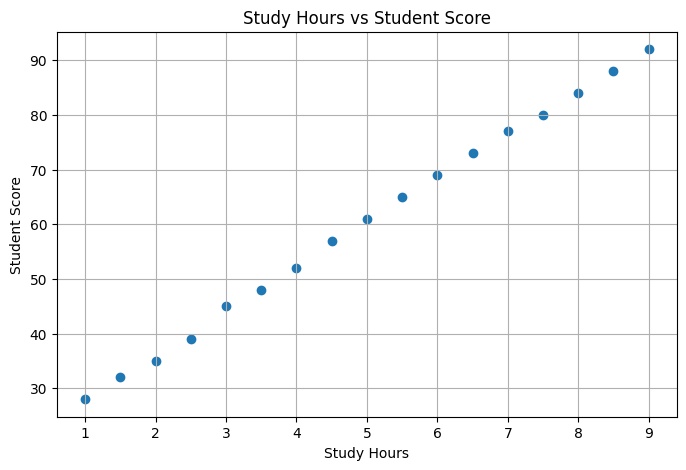

In [6]:
plt.figure(figsize=(8,5))
plt.scatter(student_data["Study_Hours"], student_data["Score"])
plt.xlabel("Study Hours")
plt.ylabel("Student Score")
plt.title("Study Hours vs Student Score")
plt.grid(True)
plt.show()

### Prepare Features and Target

In [7]:
X = student_data[["Study_Hours"]]
y = student_data["Score"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (17, 1)
Target shape: (17,)


### Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 12
Testing records: 5


### Train Linear Regression Model

In [9]:
student_model = LinearRegression()
student_model.fit(X_train, y_train)

print("Model trained successfully.")
print("Coefficient:", student_model.coef_[0])
print("Intercept:", student_model.intercept_)

Model trained successfully.
Coefficient: 8.092814371257486
Intercept: 19.83832335329341


### Make Predictions

In [10]:
student_predictions = student_model.predict(X_test)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(student_predictions, 2)
})

results

,Actual,Predicted
0,28,27.93
1,32,31.98
2,48,48.16
3,88,88.63
4,73,72.44


### Evaluate the Regression Model

In [11]:
mae = mean_absolute_error(y_test, student_predictions)
mse = mean_squared_error(y_test, student_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, student_predictions)

print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 3))

MAE: 0.29
MSE: 0.15
RMSE: 0.38
R² Score: 1.0


### Predict a New Student Score

In [12]:
hours = 6.0
predicted_score = student_model.predict(pd.DataFrame({"Study_Hours":[hours]}))[0]

print(f"Predicted score for {hours} study hours: {predicted_score:.2f}")

Predicted score for 6.0 study hours: 68.40


# Day 14 — House Price Prediction


In [13]:
house_data = pd.DataFrame({
    "Area_sqft": [600, 750, 900, 1050, 1200, 1350, 1500, 1700, 1900, 2100, 2300, 2500],
    "Price_Lakh": [28, 34, 39, 45, 51, 58, 64, 73, 82, 91, 99, 108]
})

house_data

,Area_sqft,Price_Lakh
0,600,28
1,750,34
2,900,39
3,1050,45
4,1200,51
5,1350,58
6,1500,64
7,1700,73
8,1900,82
9,2100,91


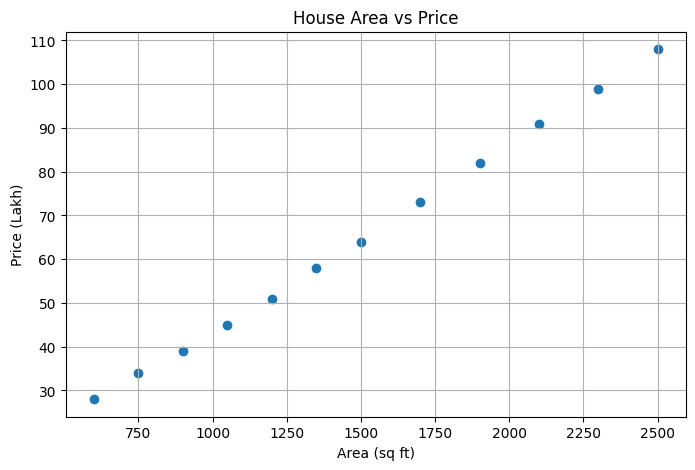

In [14]:
plt.figure(figsize=(8,5))
plt.scatter(house_data["Area_sqft"], house_data["Price_Lakh"])
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (Lakh)")
plt.title("House Area vs Price")
plt.grid(True)
plt.show()

In [15]:
X_house = house_data[["Area_sqft"]]
y_house = house_data["Price_Lakh"]

Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_house, y_house, test_size=0.25, random_state=42
)

house_model = LinearRegression()
house_model.fit(Xh_train, yh_train)

house_predictions = house_model.predict(Xh_test)

house_results = pd.DataFrame({
    "Actual Price": yh_test.values,
    "Predicted Price": np.round(house_predictions, 2)
})

house_results

,Actual Price,Predicted Price
0,99,98.87
1,91,90.31
2,28,26.15


In [16]:
house_mae = mean_absolute_error(yh_test, house_predictions)
house_rmse = np.sqrt(mean_squared_error(yh_test, house_predictions))
house_r2 = r2_score(yh_test, house_predictions)

print("House Price Model")
print("MAE:", round(house_mae, 2))
print("RMSE:", round(house_rmse, 2))
print("R²:", round(house_r2, 3))

House Price Model
MAE: 0.89
RMSE: 1.14
R²: 0.999


### Predict Price for a New House

In [17]:
new_area = 1600

predicted_price = house_model.predict(
    pd.DataFrame({"Area_sqft":[new_area]})
)[0]

print(f"Predicted price for {new_area} sq ft: {predicted_price:.2f} lakh")

Predicted price for 1600 sq ft: 68.92 lakh


# Day 15 — Iris Flower Classification


In [18]:
iris = load_iris()

iris_df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

iris_df["target"] = iris.target
iris_df["species"] = iris_df["target"].map(
    dict(enumerate(iris.target_names))
)

iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Inspect the Dataset

In [19]:
print("Shape:", iris_df.shape)
print("\nClass distribution:")
print(iris_df["species"].value_counts())

iris_df.describe()

Shape: (150, 6)

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Prepare Features and Target

In [20]:
X_iris = iris.data
y_iris = iris.target

Xi_train, Xi_test, yi_train, yi_test = train_test_split(
    X_iris,
    y_iris,
    test_size=0.20,
    random_state=42,
    stratify=y_iris
)

print("Training samples:", len(Xi_train))
print("Testing samples:", len(Xi_test))

Training samples: 120
Testing samples: 30


### Train Logistic Regression

In [21]:
iris_model = LogisticRegression(max_iter=300)
iris_model.fit(Xi_train, yi_train)

print("Classification model trained successfully.")

Classification model trained successfully.


### Predict Test Data

In [22]:
iris_predictions = iris_model.predict(Xi_test)

prediction_table = pd.DataFrame({
    "Actual": [iris.target_names[i] for i in yi_test],
    "Predicted": [iris.target_names[i] for i in iris_predictions]
})

prediction_table.head(10)

,Actual,Predicted
0,setosa,setosa
1,virginica,virginica
2,versicolor,versicolor
3,versicolor,versicolor
4,setosa,setosa
5,versicolor,versicolor
6,setosa,setosa
7,setosa,setosa
8,virginica,virginica
9,versicolor,versicolor


### Evaluate Classification Performance

In [23]:
accuracy = accuracy_score(yi_test, iris_predictions)

print("Accuracy:", round(accuracy, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(yi_test, iris_predictions))

print("\nClassification Report:")
print(classification_report(
    yi_test,
    iris_predictions,
    target_names=iris.target_names
))

Accuracy: 0.967

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Predict a New Iris Flower

In [24]:
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

predicted_class = iris_model.predict(new_flower)[0]

print("Predicted flower:",
      iris.target_names[predicted_class])

Predicted flower: setosa


# Day 16 — Compare Regression and Classification

| Feature | Regression | Classification |
|---|---|---|
| Output | Numerical value | Category/class |
| Example | Student score | Iris species |
| Example | House price | Pass/Fail |
| Common beginner model | Linear Regression | Logistic Regression |
| Metrics | MAE, RMSE, R² | Accuracy, Precision, Recall, F1 |
